### Übung 4 Clustering 1



#### Aufgabe 1 (10)

Verwenden Sie den Weindatensatz aus dem letzten Übungsblatt. 

__a)__ Versuchen Sie das Problem um den unbekannten Wein mit hierarchischem Clustering zu lösen. Clustern Sie auf den skalierten Daten und verwenden Sie die unterschiedlichen Linkagemethoden (‘ward’, ‘complete’, ‘average’, ‘single’)  



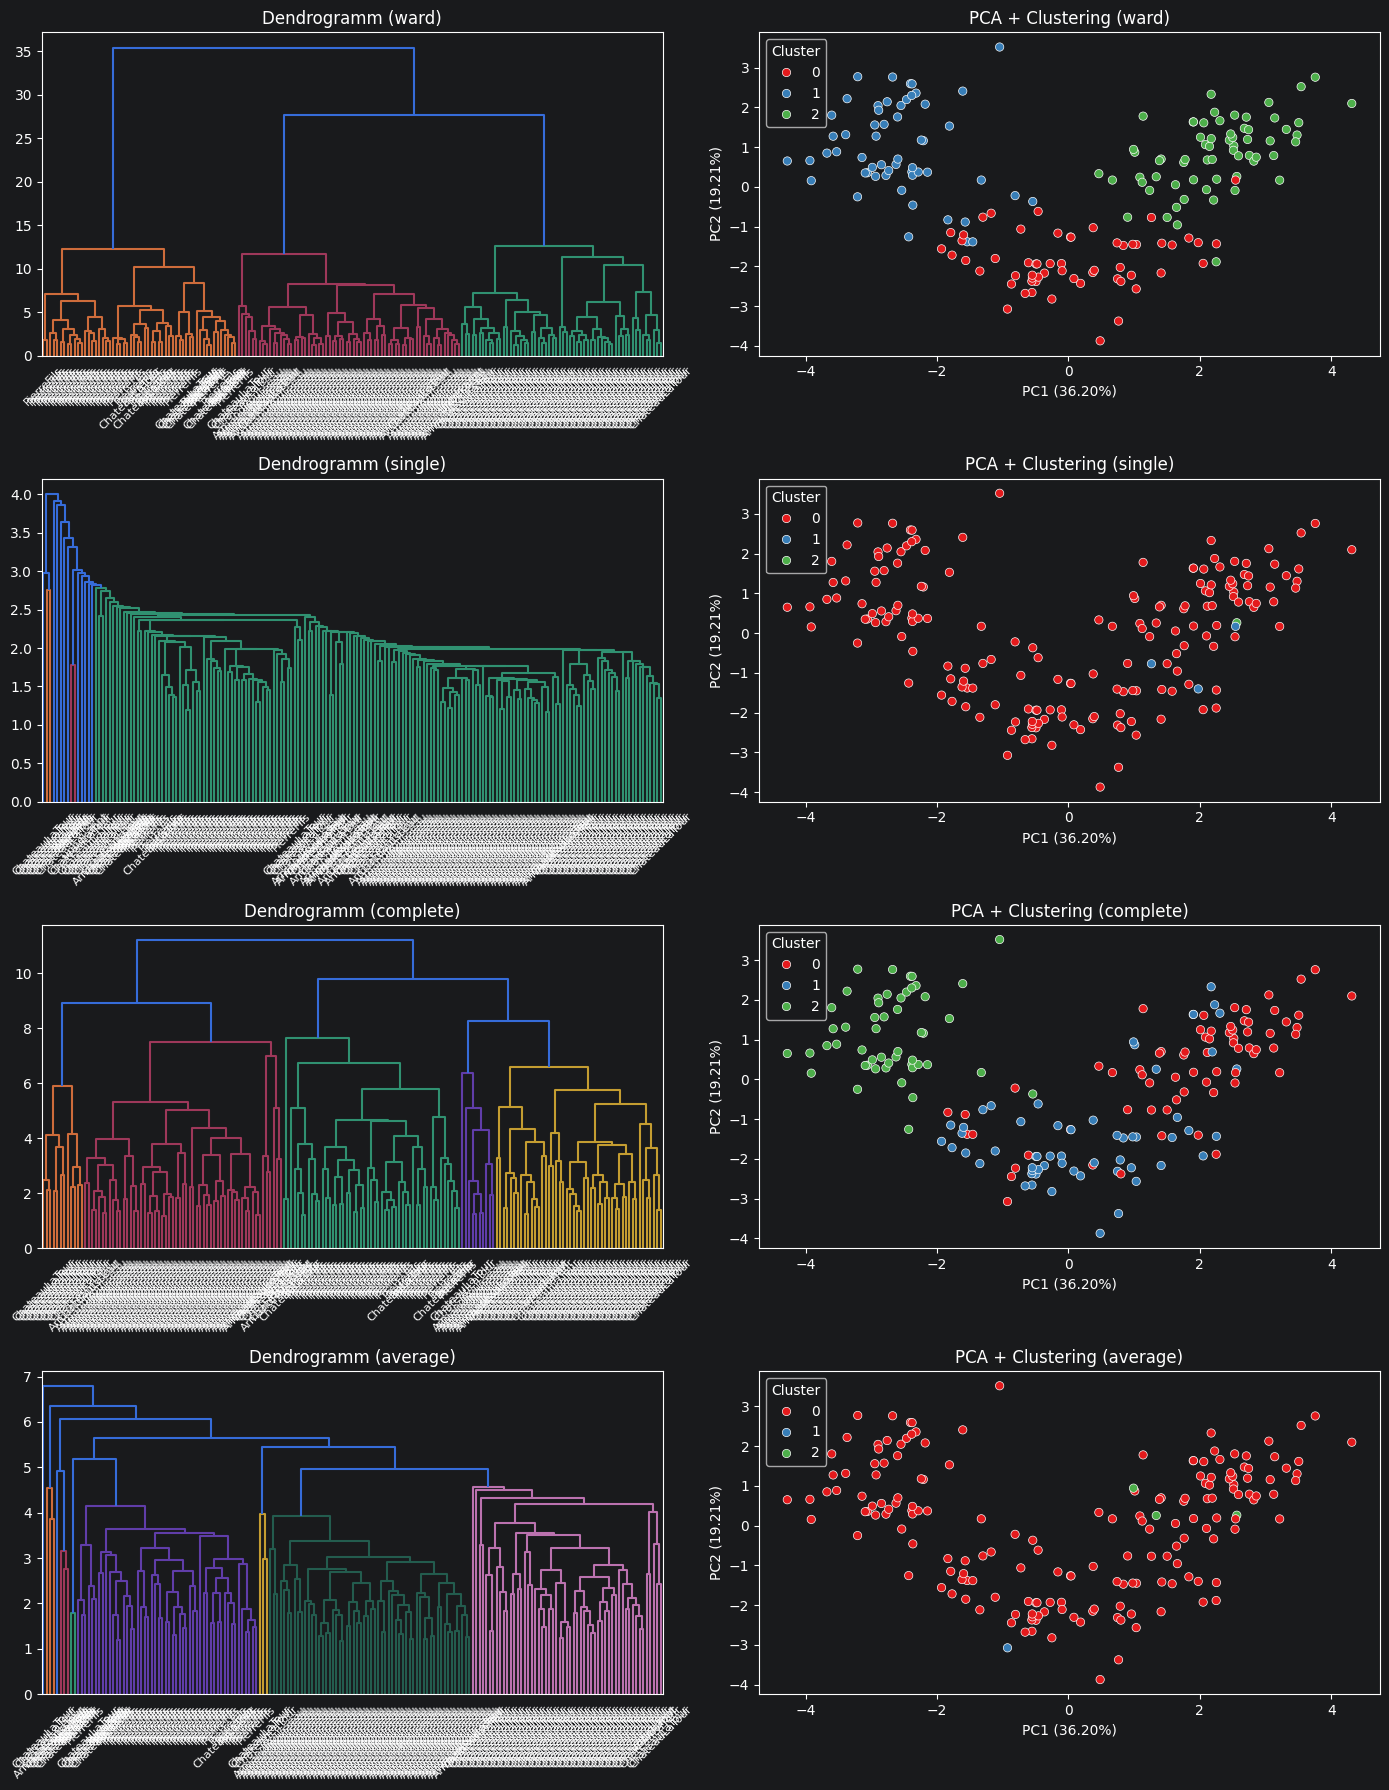

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

wine = pd.read_csv("wine_final.txt", sep=",")

features = wine.drop(columns="Weingut")

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

methods = ["ward", "single", "complete", "average"]

fig, axes = plt.subplots(len(methods), 2, figsize=(14, 18))

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

base_pca = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
base_pca["Weingut"] = wine["Weingut"]

for i, method in enumerate(methods):

    # CLUSTERING
    linkage_matrix = sch.linkage(scaled, method=method)

    model = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = model.fit_predict(scaled)

    df_plot = base_pca.copy()
    df_plot["Cluster"] = labels

    # DENDROGRAMM
    ax1 = axes[i, 0]
    sch.dendrogram(
        linkage_matrix,
        labels=wine["Weingut"].values,
        leaf_rotation=45,
        leaf_font_size=8,
        ax=ax1
    )
    ax1.set_title(f"Dendrogramm ({method})")

    # PCA PLOT
    ax2 = axes[i, 1]

    sns.scatterplot(
        data=df_plot,
        x="PC1",
        y="PC2",
        hue="Cluster",
        palette="Set1",
        ax=ax2
    )

    ax2.set_title(f"PCA + Clustering ({method})")
    ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
    ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")

plt.tight_layout()
plt.show()

In [19]:
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(scaled)
wine["Clusters via Ward"] = labels

unbekannt_cluster = wine[wine["Weingut"] == "unbekannt"]["Clusters via Ward"].iat[0]

haeufigster_name = (
    wine[
        (wine["Clusters via Ward"] == unbekannt_cluster) &
        (wine["Weingut"] != "unbekannt")
    ]["Weingut"]
    .mode()[0]
)

wine.loc[wine["Weingut"] == "unbekannt", "Weingut"] = haeufigster_name

base_pca["Weingut"] = wine["Weingut"]

__b)__ Verwenden Sie weiterhin das hierarchische Clustern mit beliebiger Linkage Methode, legen Sie eine sinnvolle Clustergröße fest, clustern Sie die Daten erneut und lassen Sie sich dann die PCA mit den Punkten gefärbt nach Cluster und geformt nach Weingut anzeigen. Erklären Sie das Ergebnis.

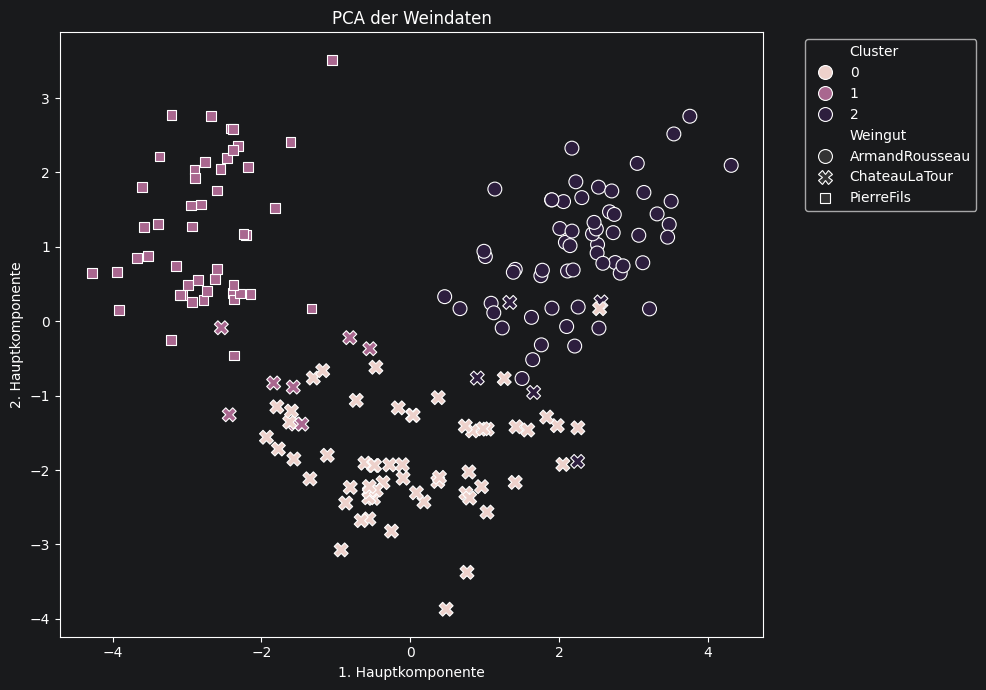

In [20]:


base_pca["Cluster"] = labels

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=base_pca,
    x="PC1",
    y="PC2",
    hue="Cluster",      # Farbe nach Cluster
    style="Weingut",    # Form nach Weingut
    s=100
)

plt.title("PCA der Weindaten")
plt.xlabel("1. Hauptkomponente")
plt.ylabel("2. Hauptkomponente")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Aufgabe 2 Mickey Mouse Datensatz (10)

Eine Standardaufgabe für Clusteringalgorithmen besteht darin, 3 Cluster richtig zu trennen. 
Der erste Datensatz ist _clusters3.csv_ und der zweite Datensatz ist _mickeythemouse.csv_. Skalieren Sie die Daten für diese Aufgabe bitte nicht.

__a)__ Lesen Sie beide Datensätze in Python ein und erstellen Sie je einen Scatterplot

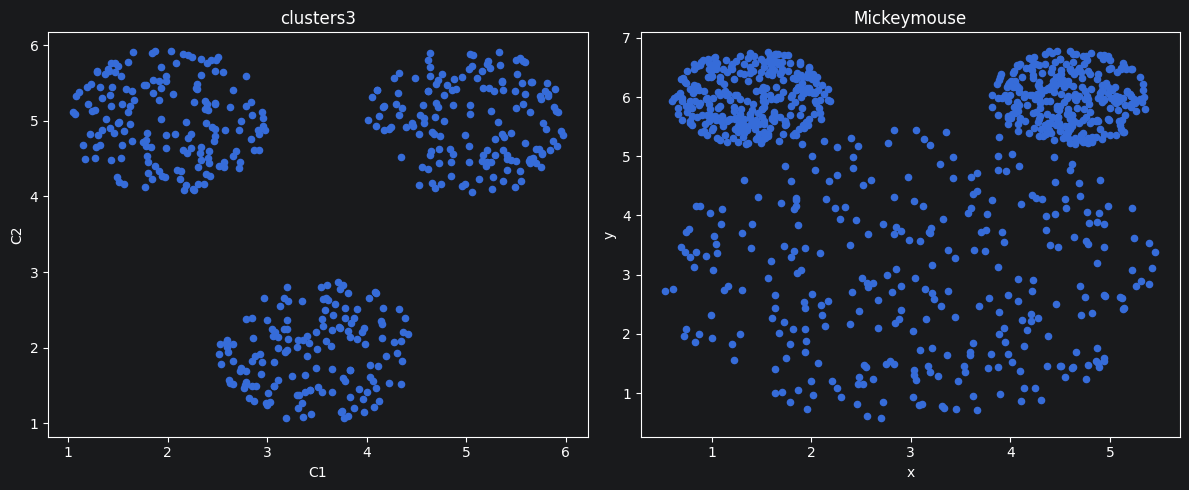

          x         y
0  3.880717  3.130829
1  2.725952  0.847154
2  2.424421  4.807137
3  2.547801  1.434970
4  3.422402  4.980830
         C1        C2
0  1.541361  4.675249
1  1.847136  5.364254
2  2.131797  4.330446
3  2.404414  5.138453
4  1.760709  5.469187


In [40]:
plt.close("all")

clusters3 = pd.read_csv("clusters3.csv", header=None, names=["C1", "C2"])
mickey = pd.read_csv("mickeythemouse.csv", sep=",")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(clusters3["C1"], clusters3["C2"], s=20)
axes[0].set_title("clusters3")
axes[0].set_xlabel("C1")
axes[0].set_ylabel("C2")

axes[1].scatter(mickey["x"], mickey["y"], s=20)
axes[1].set_title("Mickeymouse")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()
print(mickey.head())
print(clusters3.head())

__b)__ Wenden sie hierarchisches Clustern auf den ersten (einfachen) Datensatz an. Verwenden Sie immer 3 Cluster und markieren Sie diese farblich in einem Scatterplot. Probieren Sie unterschiedliche Distanzmaße (“euclidean”, “l1”, “l2”, “manhattan”, “cosine”) und Clusterstrategien (‘ward’, ‘complete’, ‘average’, ‘single’) aus.
Bevor Sie starten: Was ist _cosine_, was ist _l1_ und _l2_?

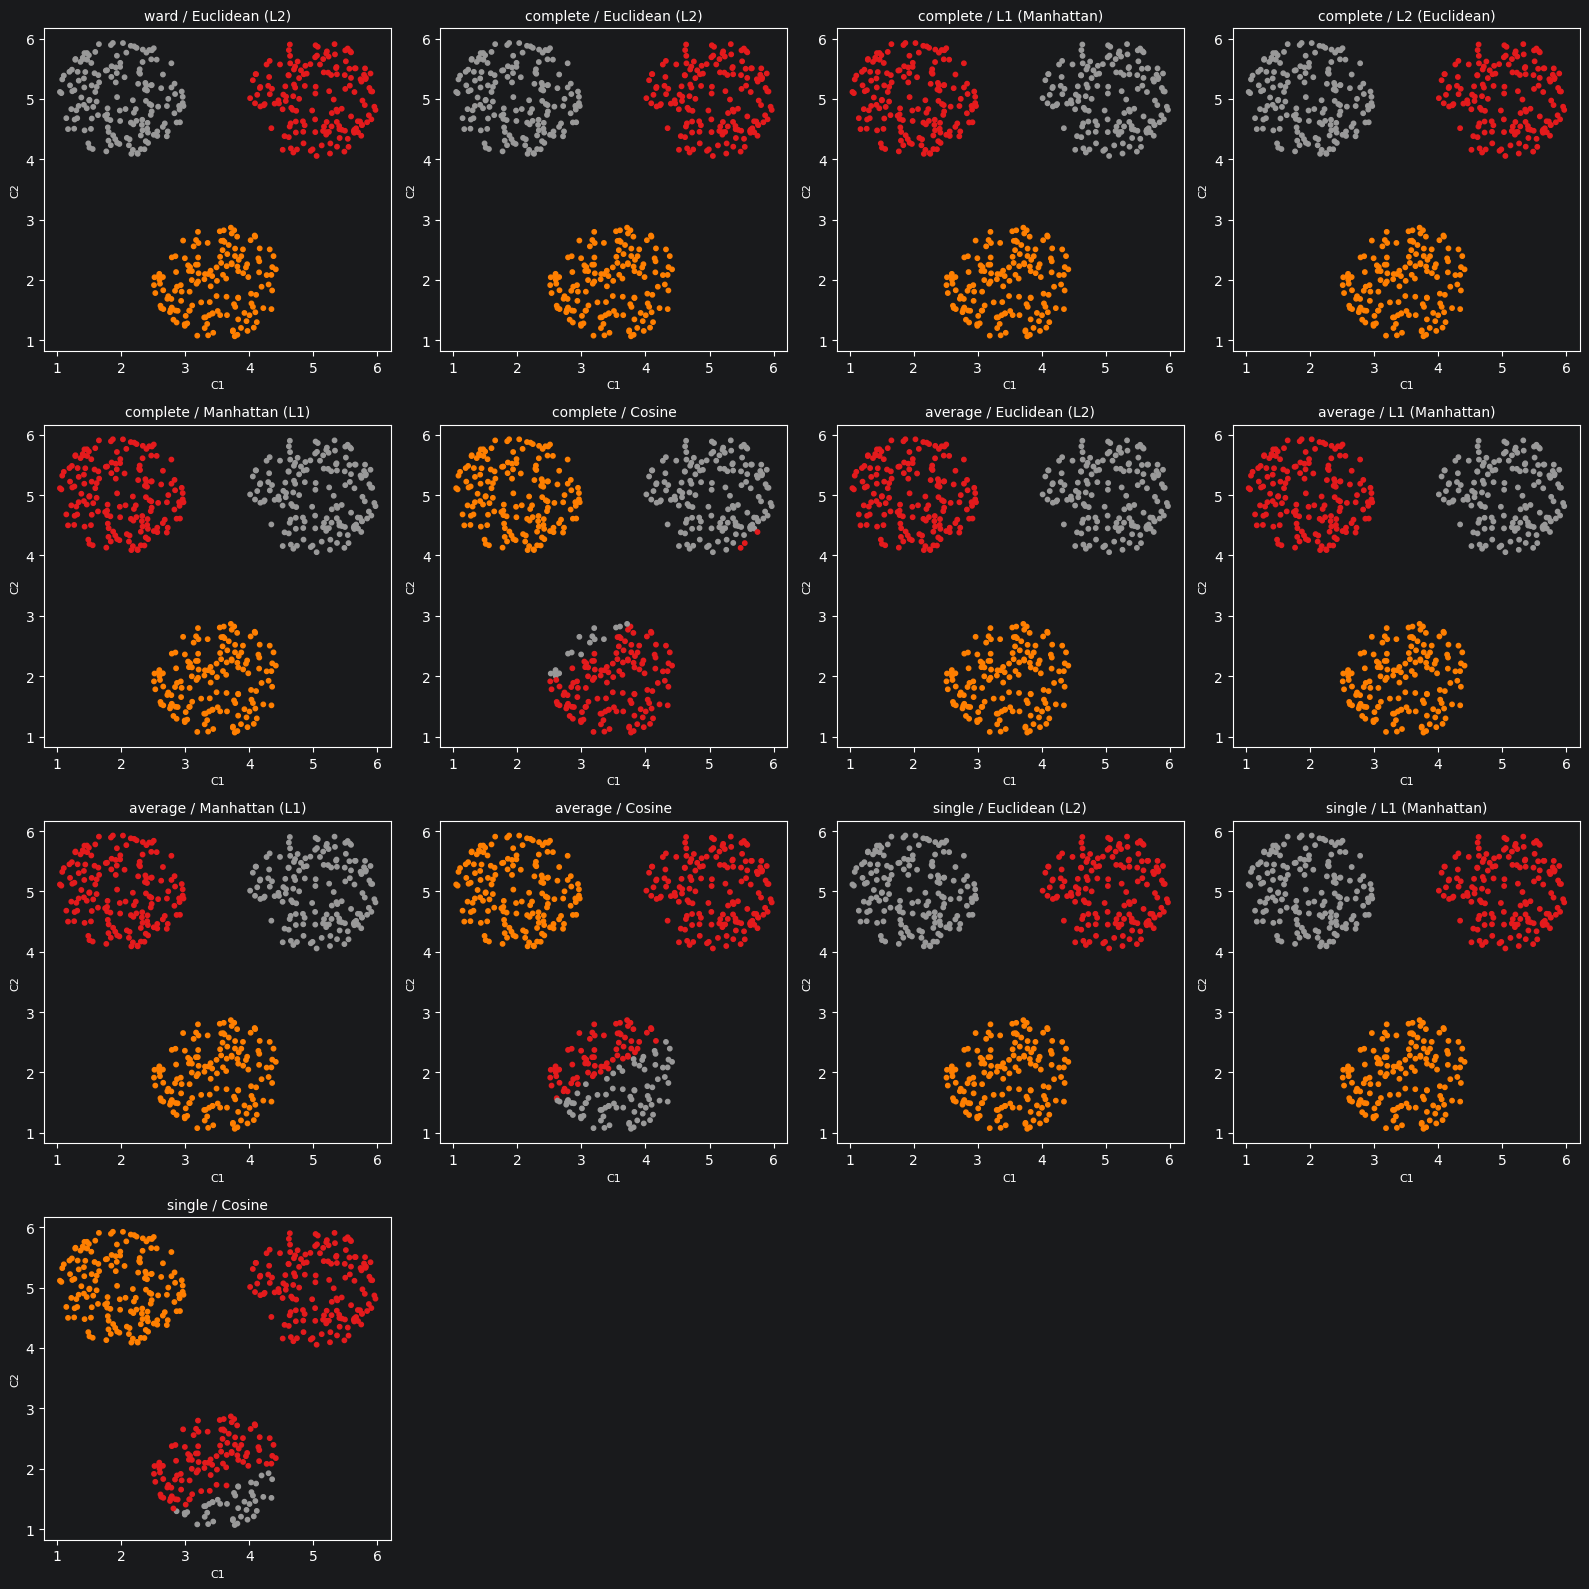

In [38]:
combos = [
    ("euclidean", "ward"),
    ("euclidean", "complete"),
    ("l1", "complete"),
    ("l2", "complete"),
    ("manhattan", "complete"),
    ("cosine", "complete"),
    ("euclidean", "average"),
    ("l1", "average"),
    ("manhattan", "average"),
    ("cosine", "average"),
    ("euclidean", "single"),
    ("l1", "single"),
    ("cosine", "single"),
]
metric_labels = {
    "euclidean": "Euclidean (L2)",
    "l1": "L1 (Manhattan)",
    "l2": "L2 (Euclidean)",
    "manhattan": "Manhattan (L1)",
    "cosine": "Cosine"
}

n_cols = 4
n_rows = -(-len(combos) // n_cols)  # aufrunden

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, (metric, linkage) in enumerate(combos):
    model = AgglomerativeClustering(n_clusters=3, metric=metric, linkage=linkage)
    labels = model.fit_predict(clusters3[["C1", "C2"]])

    axes[i].scatter(clusters3["C1"], clusters3["C2"], c=labels, cmap="Set1", s=10)
    axes[i].set_title(f"{linkage} / {metric_labels[metric]}", fontsize=10)
    axes[i].set_xlabel("C1", fontsize=8)
    axes[i].set_ylabel("C2", fontsize=8)

# leere Subplots ausblenden
for j in range(len(combos), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

__b)__ Verwenden Sie nun den Mickey Mouse Datensatz mit den Linkage- und Distanzmethoden von oben.

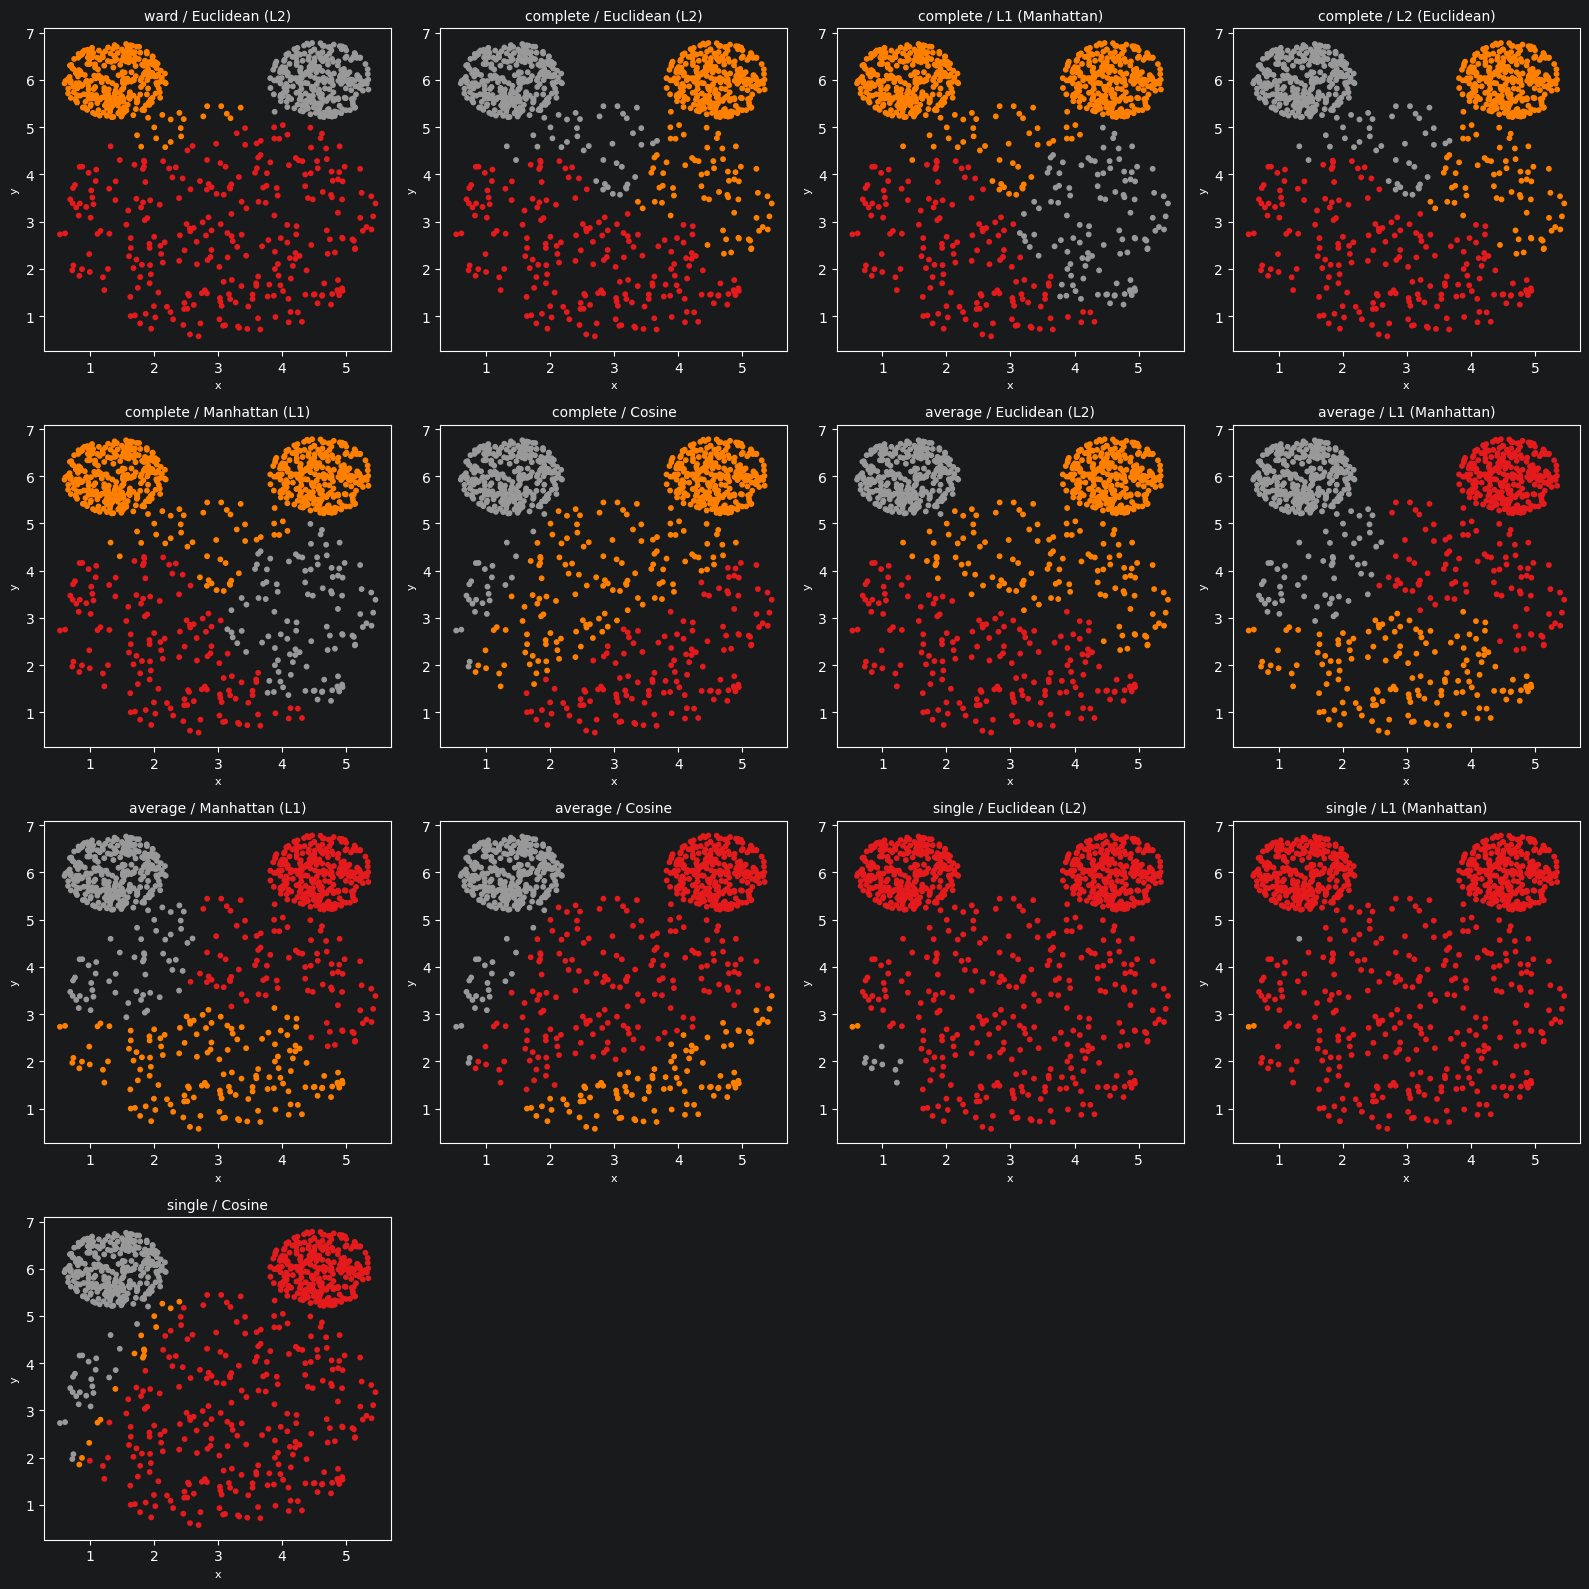

In [43]:

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, (metric, linkage) in enumerate(combos):
    model = AgglomerativeClustering(n_clusters=3, metric=metric, linkage=linkage)
    labels = model.fit_predict(mickey[["x", "y"]])

    axes[i].scatter(mickey["x"], mickey["y"], c=labels, cmap="Set1", s=10)
    axes[i].set_title(f"{linkage} / {metric_labels[metric]}", fontsize=10)
    axes[i].set_xlabel("x", fontsize=8)
    axes[i].set_ylabel("y", fontsize=8)

# leere Subplots ausblenden
for j in range(len(combos), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Aufgabe 3 Genespressionsdaten von Rauchern (10)

Gegeben sind Ihnen Daten über die Expressionsstärke von Genen, die sich bei Rauchern und Nicht-Rauchern unterscheiden. Sie möchten im Folgenden anhand der Genexpression die Personen (Raucher/Nicht-Raucher) clustern.

__a)__ Lesen Sie die drei Datensätze _GSE4498_series_data.txt_, _metadata.txt_ und _regulatedGenes.txt_ in Python ein. Filtern Sie die Daten der Datei _GSE4498_series_data.txt_, so dass nur noch die Daten zu den Genen übrig bleiben, die in _regulatedGenes.txt_ vorhanden sind.

In [87]:
metadata = pd.read_csv("metadata.txt", sep="\s+", header=None, names=["Smoker"])

gse = pd.read_csv("GSE4498_series_data.txt", sep="\t")
regulated = pd.read_csv("regulatedGenes.txt", header=None, names=["ProbeID"])
regulated_ids = regulated["ProbeID"].values

gse_filtered = gse[gse["ID_REF"].isin(regulated_ids)]

print(gse_filtered.shape)
print(gse_filtered.head())
print(metadata.head())

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\toyel\AppData\Local\Temp\ipykernel_13476\1787362348.py:1: SyntaxWarning: invalid escape sequence '\s'
  metadata = pd.read_csv("metadata.txt", sep="\s+", header=None, names=["Smoker"])


(220, 23)
            ID_REF   GSM101095   GSM101096   GSM101097   GSM101098  \
8        1405_i_at  285.174400  423.060580  129.430970  113.187570   
104   1552398_a_at   13.172574   49.682560   16.892262   13.604702   
134   1552448_a_at   35.779835   21.564425   55.343640   41.423700   
985     1553602_at  350.444520  288.711030  272.211500  314.390300   
1390  1554190_s_at  563.030000  545.193500  491.452270  508.490840   

       GSM101099   GSM101100   GSM101101   GSM101102   GSM101103  ...  \
8     460.655240  123.801544   60.368977  100.791470  125.526350  ...   
104    22.640104   11.642102   17.282488   24.778189   18.991910  ...   
134    16.340673   35.685577   61.647625   87.228710   40.378925  ...   
985   320.293730  392.454160  290.712300  293.856800  165.496670  ...   
1390  583.440900  639.527470  588.862600  469.101780  450.449800  ...   

        GSM101107    GSM101108    GSM101109    GSM101110   GSM101111  \
8      155.577560  1713.707500   118.035355   207.827820  

__b)__ Stellen Sie ein Boxplot über jede Spalte der GSE Daten dar.

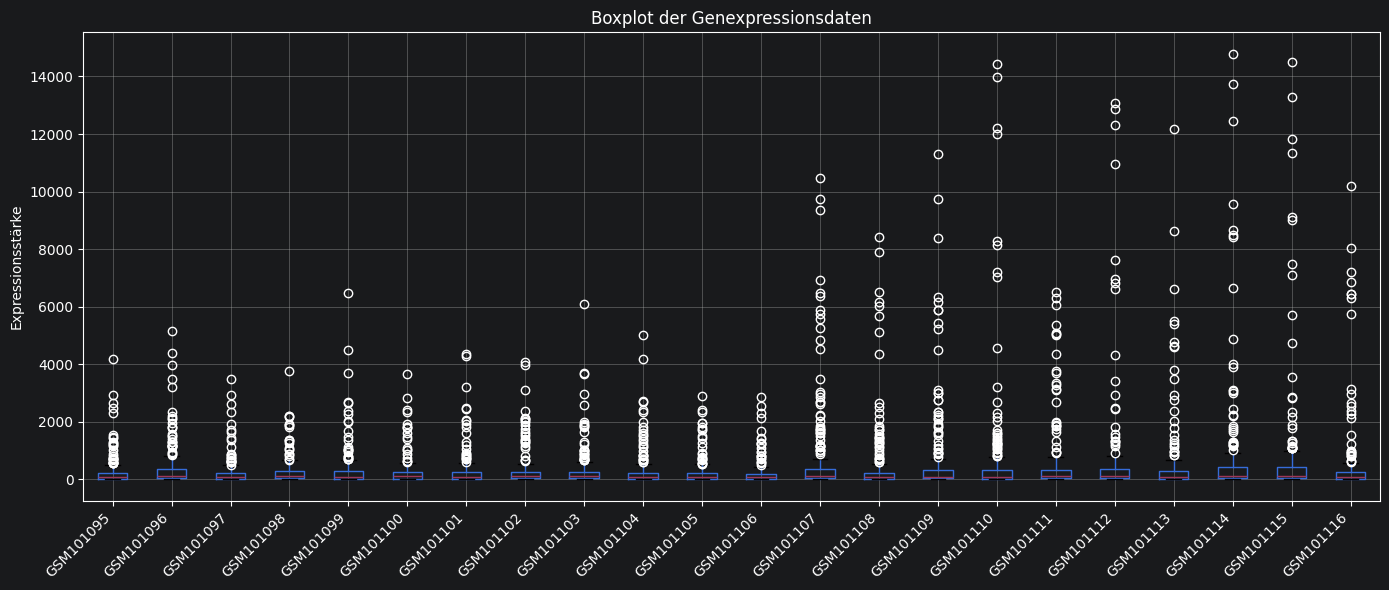

In [88]:
plt.figure(figsize=(14, 6))

gse_filtered.drop(columns="ID_REF").boxplot()

plt.xticks(rotation=45, ha="right")
plt.title("Boxplot der Genexpressionsdaten")
plt.ylabel("Expressionsstärke")
plt.tight_layout()
plt.show()

__c)__ Führen Sie eine Standardskalierung über die Spalten der GSE Daten durch. Erstellen Sie erneut Boxplots je Spalte. Warum skalieren Sie in diesem Fall über die Spalten und nicht über die Zeilen?

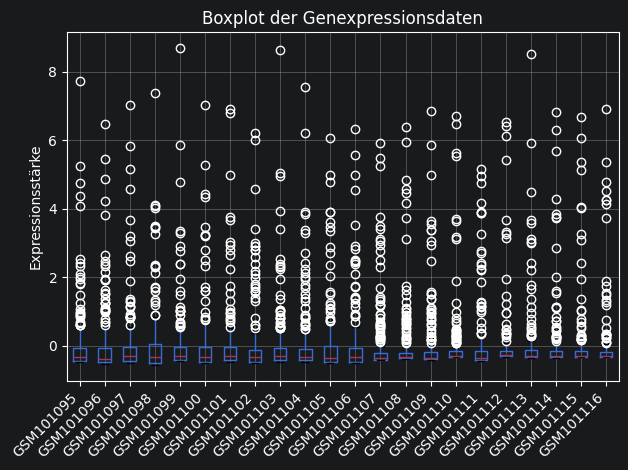

In [89]:
features = gse_filtered.drop(columns="ID_REF")
gse_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)
gse_scaled["ID_REF"] = gse_filtered["ID_REF"].values

gse_scaled.drop(columns="ID_REF").boxplot()

plt.xticks(rotation=45, ha="right")
plt.title("Boxplot der Genexpressionsdaten")
plt.ylabel("Expressionsstärke")
plt.tight_layout()
plt.show()

__d)__
Transformieren Sie die GSE-Matrix und fügen Sie eine Spalte mit der Information Raucher/Nicht-Raucher hinzu.

In [90]:
gse_T = gse_filtered.set_index("ID_REF").T
gse_T["Smoker"] = metadata["Smoker"]
print(gse_T.head())


ID_REF     1405_i_at  1552398_a_at  1552448_a_at  1553602_at  1554190_s_at  \
GSM101095  285.17440     13.172574     35.779835   350.44452     563.03000   
GSM101096  423.06058     49.682560     21.564425   288.71103     545.19350   
GSM101097  129.43097     16.892262     55.343640   272.21150     491.45227   
GSM101098  113.18757     13.604702     41.423700   314.39030     508.49084   
GSM101099  460.65524     22.640104     16.340673   320.29373     583.44090   

ID_REF     1554663_a_at  1555330_at  1555759_a_at  1555854_at  1556879_at  \
GSM101095    237.980440   60.181465     235.04587    76.55266   64.835175   
GSM101096     48.533817   76.049446     382.85510   259.28260  168.730150   
GSM101097     12.324223   66.958626     214.89830   389.12460  316.217930   
GSM101098     64.461555   64.144630      83.59338   585.44916  376.758150   
GSM101099    117.004930   40.835540     313.96480   347.27210   79.439460   

ID_REF     ...  242871_at  243110_x_at  244677_at  244780_at   34210

__e)__ Stellen Sie die Daten in einer Dimensionsreduzierten Form (z.B. PCA) dar. Färben Sie die Punkte nach _smoker_ und _non_smoker_

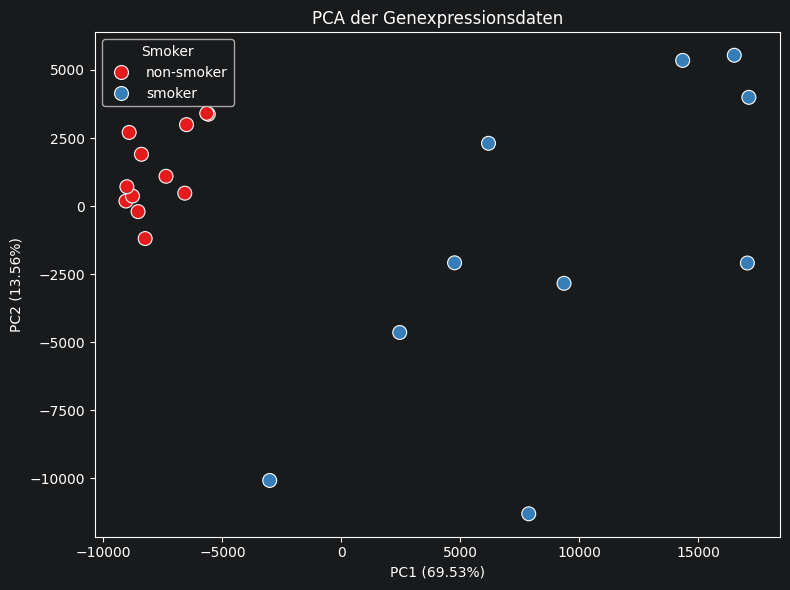

In [93]:
features = gse_T.drop(columns="Smoker")

pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
pca_df["Smoker"] = gse_T["Smoker"].values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Smoker", palette="Set1", s=100)
plt.title("PCA der Genexpressionsdaten")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.tight_layout()
plt.show()


__f)__ Verwenden Sie hierarchisches Clustering und Clustern Sie einmal die "originalen" Daten und einmal die PCA transformierten Daten (mit den ersten beiden Hauptkomponenten). Erstellen Sie je ein Dendrogramm.

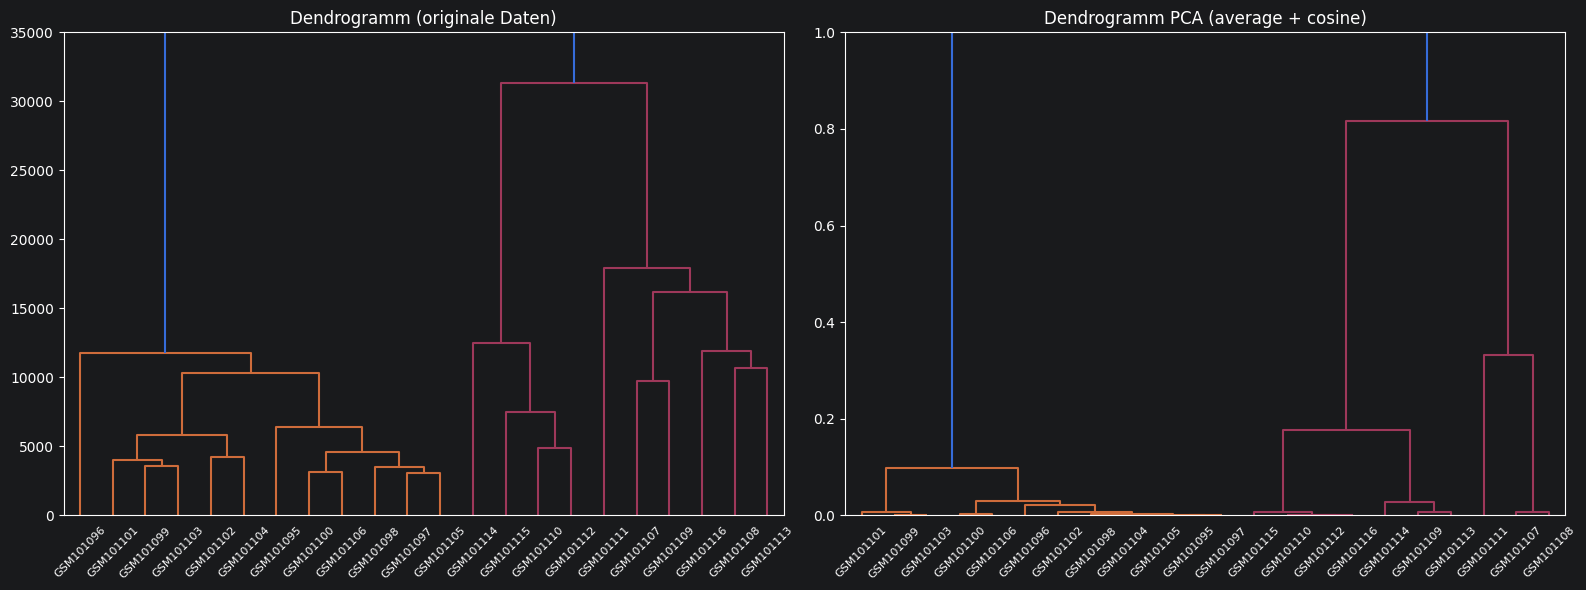

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# Originale Daten
linkage_original = sch.linkage(features, method="ward", metric="euclidean")

sch.dendrogram(
    linkage_original,
    labels=gse_T.index.values,
    leaf_rotation=45,
    leaf_font_size=8,
    ax=axes[0]
)
axes[0].set_title("Dendrogramm (originale Daten)")
axes[0].set_ylim(0, 35000)


# PCA Daten (average + cosine)
pca_features = pca_df.drop(columns="Smoker")

linkage_pca = sch.linkage(pca_features, method="average", metric="cosine")

sch.dendrogram(
    linkage_pca,
    labels=gse_T.index.values,
    leaf_rotation=45,
    leaf_font_size=8,
    ax=axes[1]
)
axes[1].set_title("Dendrogramm PCA (average + cosine)")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

'__g)__ Erstellen Sie je zwei PCA-Scatterplots, färben Sie die Daten jeweils nach den oben ermittelten Clustern. Wählen Sie als Clusteranzahl zwei aus. Formen Sie die Punkte nach Raucher/Nicht-Raucher.

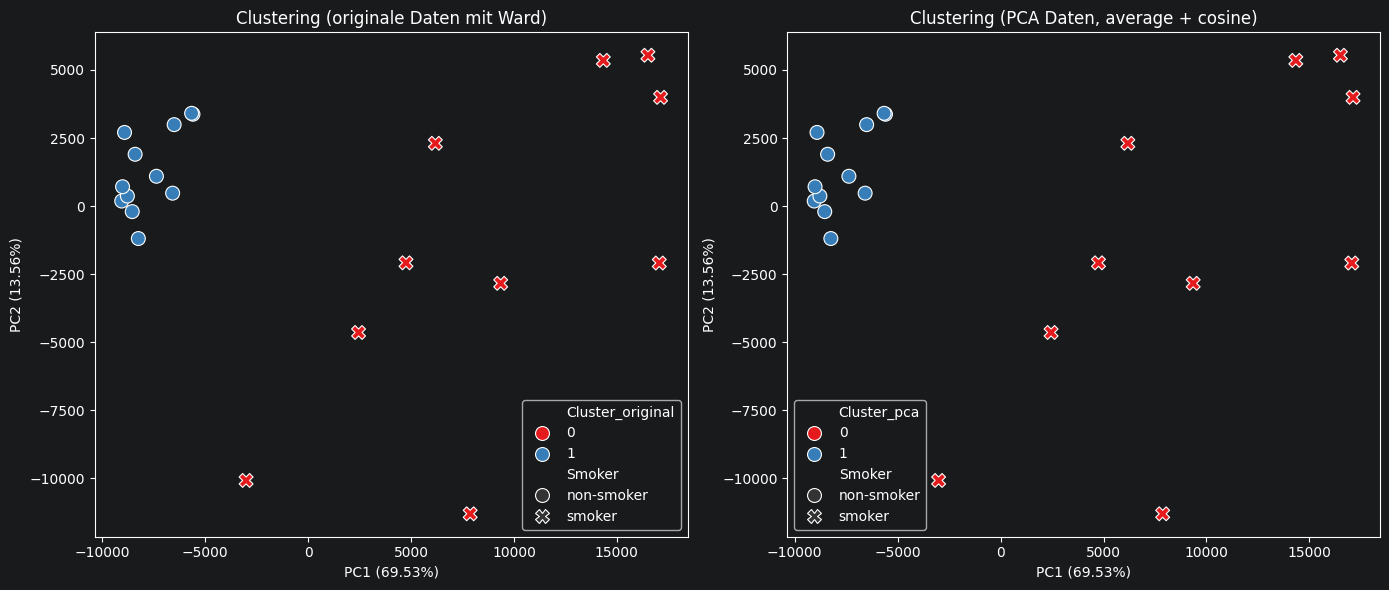

In [114]:

# Clustering
model_original = AgglomerativeClustering(n_clusters=2, metric="euclidean", linkage="ward")
labels_original = model_original.fit_predict(features)

model_pca = AgglomerativeClustering(n_clusters=2, metric="cosine", linkage="average")
labels_pca = model_pca.fit_predict(pca_features)

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original Daten
pca_df["Cluster_original"] = labels_original
sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="Cluster_original",
    style="Smoker",
    palette="Set1",
    s=100,
    ax=axes[0]
)
axes[0].set_title("Clustering (originale Daten mit Ward)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")

# PCA Daten
pca_df["Cluster_pca"] = labels_pca
sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="Cluster_pca",
    style="Smoker",
    palette="Set1",
    s=100,
    ax=axes[1]
)
axes[1].set_title("Clustering (PCA Daten, average + cosine)")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")

plt.tight_layout()
plt.show()